In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import time


### 1. Exploração e Pré-processamento dos Dados


In [5]:
try:
    df_treino = pd.read_csv('treino.csv')
    df_teste = pd.read_csv('teste.csv')
    print("Arquivos carregados com sucesso!")
except FileNotFoundError:
    print("Erro: Verifique se 'treino.csv' e 'teste.csv' estão no mesmo diretório do seu notebook.")


Arquivos carregados com sucesso!


In [6]:
# --- Análise Inicial ---
print("\n--- Análise do Dataset de Treino ---")
print("Dimensões do dataset:", df_treino.shape)
print("\nInformações sobre as colunas:")
print(df_treino.info())


--- Análise do Dataset de Treino ---
Dimensões do dataset: (8000, 31)

Informações sobre as colunas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f0      8000 non-null   float64
 1   f1      8000 non-null   float64
 2   f2      8000 non-null   float64
 3   f3      8000 non-null   float64
 4   f4      8000 non-null   float64
 5   f5      8000 non-null   float64
 6   f6      8000 non-null   float64
 7   f7      8000 non-null   float64
 8   f8      8000 non-null   float64
 9   f9      8000 non-null   float64
 10  f10     8000 non-null   float64
 11  f11     8000 non-null   float64
 12  f12     8000 non-null   float64
 13  f13     8000 non-null   float64
 14  f14     8000 non-null   float64
 15  f15     8000 non-null   float64
 16  f16     8000 non-null   float64
 17  f17     8000 non-null   float64
 18  f18     8000 non-null   float64
 19  f19     8

In [7]:
print("\n--- Estatísticas Descritivas do Dataset de Treino ---")
print(df_treino.describe())


--- Estatísticas Descritivas do Dataset de Treino ---
                f0           f1           f2           f3           f4  \
count  8000.000000  8000.000000  8000.000000  8000.000000  8000.000000   
mean      0.003658    -0.007294    -0.006702    -0.012604     0.004689   
std       1.025109     0.991082     1.003384     0.991363     0.998436   
min      -4.295391    -4.465604    -3.817043    -3.398329    -3.856375   
25%      -0.687458    -0.676426    -0.681037    -0.670570    -0.670059   
50%       0.014626    -0.025428    -0.023186     0.000683     0.000919   
75%       0.689718     0.661613     0.659346     0.648803     0.689489   
max       3.727833     3.942331     3.829782     4.479084     3.594374   

                f5           f6           f7           f8           f9  ...  \
count  8000.000000  8000.000000  8000.000000  8000.000000  8000.000000  ...   
mean     -0.000309     0.014891     0.003992    -0.003769    -0.016483  ...   
std       1.000219     1.004325     1.003

In [8]:
# --- Verificação de Valores Faltantes ---
print("\n--- Valores Faltantes no Dataset de Treino ---")
missing_values_treino = df_treino.isnull().sum()
print(missing_values_treino[missing_values_treino > 0])
if missing_values_treino.sum() == 0:
    print("Não há valores faltantes no dataset de treino.")

print("\n--- Valores Faltantes no Dataset de Teste ---")
missing_values_teste = df_teste.isnull().sum()
print(missing_values_teste[missing_values_teste > 0])
if missing_values_teste.sum() == 0:
    print("Não há valores faltantes no dataset de teste.")



--- Valores Faltantes no Dataset de Treino ---
Series([], dtype: int64)
Não há valores faltantes no dataset de treino.

--- Valores Faltantes no Dataset de Teste ---
Series([], dtype: int64)
Não há valores faltantes no dataset de teste.


In [9]:
# Separar features (X) e target (y)
X_treino = df_treino.drop('target', axis=1)
y_treino = df_treino['target']
X_teste = df_teste.drop('target', axis=1) # Usamos o drop pois o teste também tem o target
y_teste = df_teste['target']

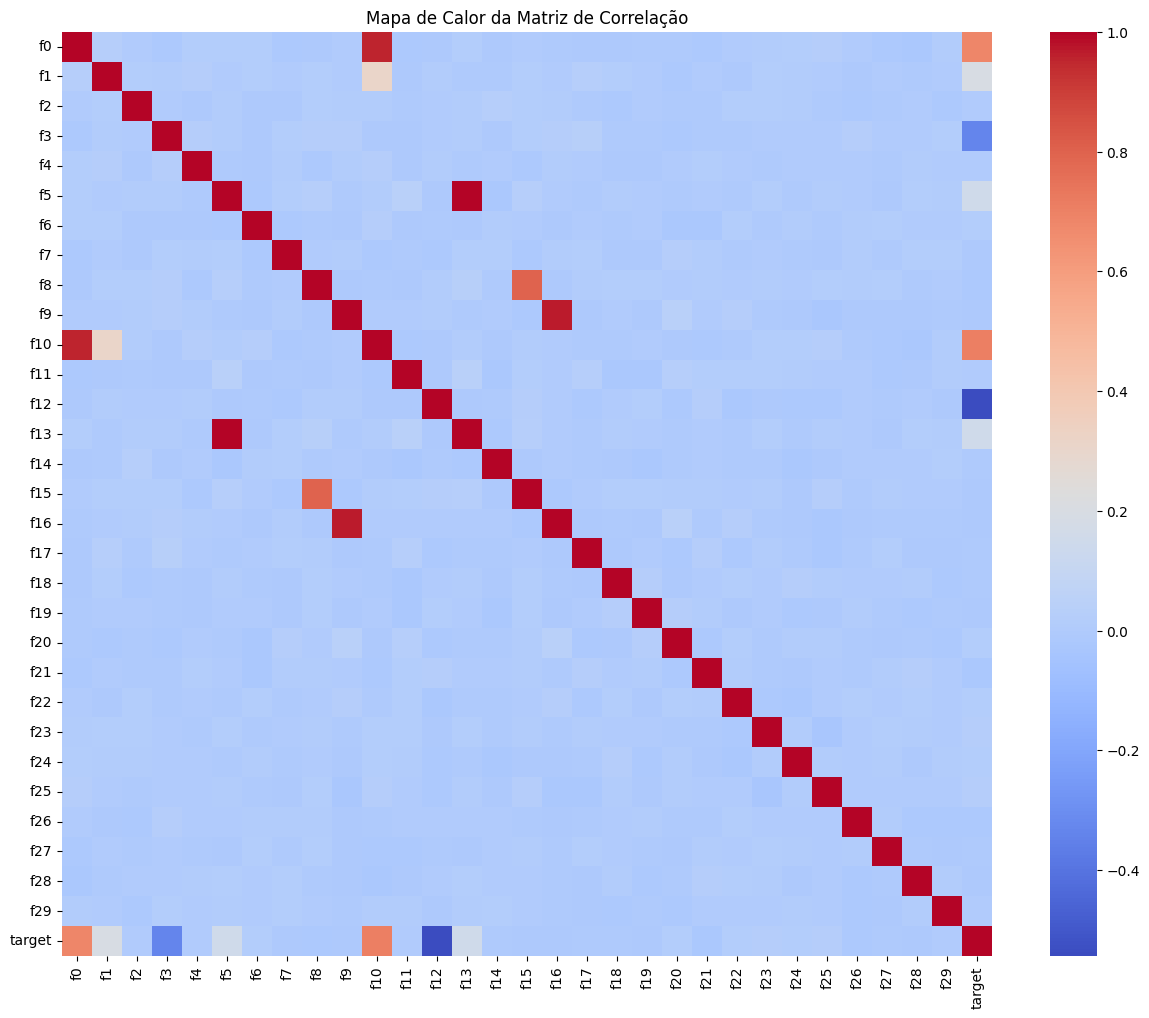

In [10]:
# --- Análise de Correlação (apenas com o dataset de treino) ---
plt.figure(figsize=(15, 12))
correlation_matrix = df_treino.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor da Matriz de Correlação')
plt.show()

In [12]:
print("\n--- Correlação das Features com o Target ---")
correlations_with_target = correlation_matrix['target'].sort_values(ascending=False)
print(correlations_with_target)


--- Correlação das Features com o Target ---
target    1.000000
f10       0.707159
f0        0.681841
f1        0.193553
f5        0.152732
f13       0.151248
f25       0.019945
f23       0.017392
f24       0.015877
f22       0.013805
f20       0.012214
f6        0.011731
f2        0.003696
f11       0.002424
f29       0.001913
f4        0.000092
f18      -0.002692
f14      -0.005397
f27      -0.006141
f17      -0.006430
f9       -0.007061
f7       -0.007124
f16      -0.007641
f19      -0.008243
f15      -0.009102
f28      -0.012603
f26      -0.012838
f8       -0.013132
f21      -0.020350
f3       -0.332493
f12      -0.543237
Name: target, dtype: float64


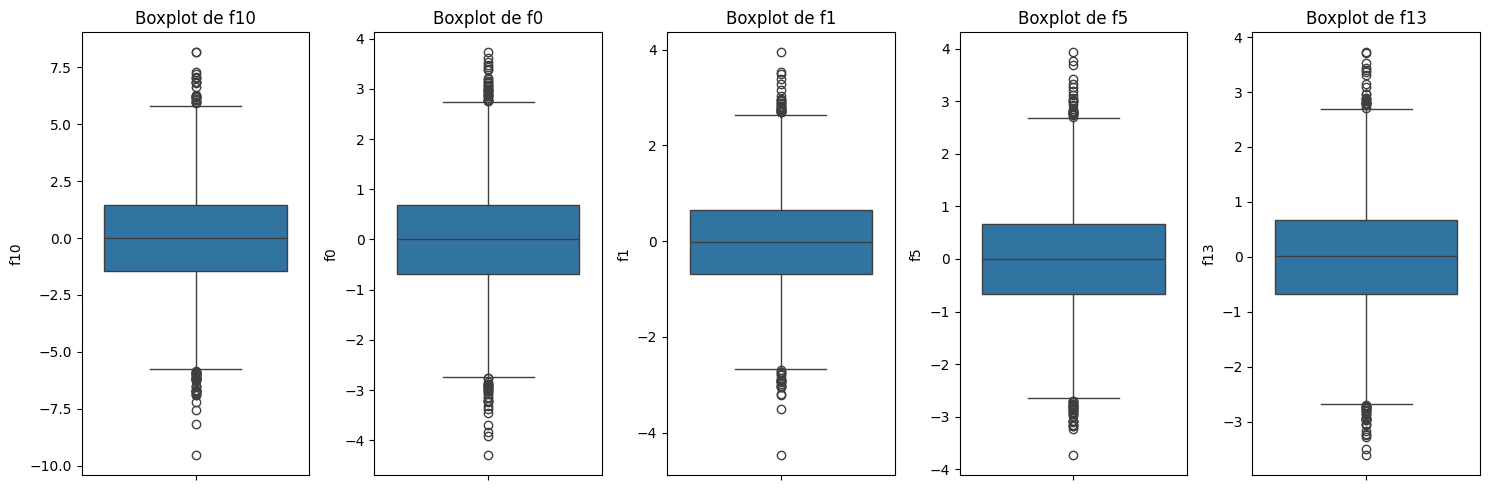

In [13]:
# --- Detecção de Outliers com Boxplots ---
# Vamos visualizar os boxplots das features com maior correlação para buscar outliers
top_features = correlations_with_target.index[1:6] # As 5 features mais correlacionadas
plt.figure(figsize=(15, 5))
for i, feature in enumerate(top_features):
    plt.subplot(1, 5, i+1)
    sns.boxplot(y=df_treino[feature])
    plt.title(f'Boxplot de {feature}')
plt.tight_layout()
plt.show()

### 2. Pré-processamento e Modelagem


In [ ]:
# --- Padronização das Features ---
scaler = StandardScaler()

In [15]:
# Ajustar o scaler APENAS com os dados de treino e depois transformar ambos os conjuntos
X_treino_scaled = scaler.fit_transform(X_treino)
X_teste_scaled = scaler.transform(X_teste)


In [16]:
# Criar DataFrames para melhor visualização (opcional)
X_treino_scaled = pd.DataFrame(X_treino_scaled, columns=X_treino.columns)
X_teste_scaled = pd.DataFrame(X_teste_scaled, columns=X_teste.columns)

print("\n--- Estatísticas após Padronização ---")
print(X_treino_scaled.describe().loc[['mean', 'std']])
print("As médias agora são próximas de 0 e os desvios-padrão próximos de 1.")


--- Estatísticas após Padronização ---
                f0            f1            f2            f3            f4  \
mean  2.886580e-17  7.105427e-18 -1.953993e-17 -8.881784e-19 -4.440892e-18   
std   1.000063e+00  1.000063e+00  1.000063e+00  1.000063e+00  1.000063e+00   

                f5            f6            f7            f8            f9  \
mean  5.329071e-18  7.105427e-18  1.110223e-17  1.776357e-17  1.598721e-17   
std   1.000063e+00  1.000063e+00  1.000063e+00  1.000063e+00  1.000063e+00   

      ...           f20           f21           f22           f23  \
mean  ... -1.310063e-17  3.574918e-17  1.598721e-17  4.796163e-17   
std   ...  1.000063e+00  1.000063e+00  1.000063e+00  1.000063e+00   

               f24           f25           f26       f27           f28  \
mean -2.842171e-17  2.664535e-18  1.554312e-17  0.000000 -5.329071e-18   
std   1.000063e+00  1.000063e+00  1.000063e+00  1.000063  1.000063e+00   

               f29  
mean -1.421085e-17  
std   1.000063e+0

In [17]:
# --- Seleção de Features (baseada nos resultados da correlação) ---
# Vamos manter apenas as features com correlação absoluta superior a 0.1
# A escolha do valor 0.1 é uma decisão de engenharia de dados baseada na sua EDA.
# features_relevantes = df_treino.corr()['target'].abs().sort_values(ascending=False)
# features_para_manter = features_relevantes[features_relevantes > 0.1].index.tolist()
# print("\nFeatures que serão mantidas:", features_para_manter)

# X_treino_final = X_treino_scaled[features_para_manter]
# X_teste_final = X_teste_scaled[features_para_manter]

# No entanto, para fins de demonstração completa, vamos manter todas as features por enquanto.
# A seleção de features pode ser ajustada depois, dependendo da performance.
X_treino_final = X_treino_scaled
X_teste_final = X_teste_scaled

In [20]:
# --- Desenvolvimento de Modelos Base ---
print("\n--- Treinando os Modelos Base ---")

# 1. Regressão Linear
lr = LinearRegression()
lr.fit(X_treino_final, y_treino)
print("Regressão Linear treinada.")

# 2. Regressão por Vetores de Suporte (SVR)
# O kernel 'rbf' é uma boa escolha padrão para dados não-lineares.
svr = SVR(kernel='rbf')
svr.fit(X_treino_final, y_treino)
print("SVR treinado.")

# 3. Árvore de Regressão
# A profundidade máxima (max_depth) é um hiperparâmetro importante para evitar overfitting.
dtr = DecisionTreeRegressor(max_depth=5, random_state=42)
dtr.fit(X_treino_final, y_treino)
print("Árvore de Regressão treinada.")

print("\nModelos base prontos para avaliação!")



--- Treinando os Modelos Base ---
Regressão Linear treinada.
SVR treinado.
Árvore de Regressão treinada.

Modelos base prontos para avaliação!


### 3. Construção dos Modelos Ensemble


In [22]:
# --- 3.1. Bagging (Random Forest Regressor) ---
print("\n--- Treinando o Random Forest Regressor ---")
# O número de estimadores (n_estimators) e a profundidade máxima (max_depth)
# são hiperparâmetros importantes para evitar overfitting.
rfr = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rfr.fit(X_treino_final, y_treino)
print("Random Forest Regressor treinado com sucesso!")


--- Treinando o Random Forest Regressor ---
Random Forest Regressor treinado com sucesso!


In [23]:
# --- 3.2. Boosting (Gradient Boosting Regressor) ---
print("\n--- Treinando o Gradient Boosting Regressor ---")
# O learning_rate e n_estimators são cruciais para o ajuste fino.
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbr.fit(X_treino_final, y_treino)
print("Gradient Boosting Regressor treinado com sucesso!")


--- Treinando o Gradient Boosting Regressor ---
Gradient Boosting Regressor treinado com sucesso!


In [25]:
# --- 3.3. Stacking (Voting Regressor) ---
print("\n--- Treinando o Voting Regressor ---")
# Criamos uma lista com os modelos base para o VotingRegressor
# Usamos os modelos já treinados
base_models = [
    ('lr', lr),
    ('svr', svr),
    ('dtr', dtr)
]

# O 'VotingRegressor' fará a média das predições dos modelos base.
# O 'weights' pode ser ajustado com base na performance de cada modelo.
# Por exemplo, se o SVR for o melhor, você pode dar um peso maior a ele.
# Exemplo: weights=[1, 2, 1]
vr = VotingRegressor(estimators=base_models)
vr.fit(X_treino_final, y_treino)
print("Voting Regressor treinado com sucesso!")
print("\nTodos os modelos de ensemble estão prontos!")



--- Treinando o Voting Regressor ---
Voting Regressor treinado com sucesso!

Todos os modelos de ensemble estão prontos!


### 4. Monitoramento e registro de métricas durante o treinamento:

In [27]:
# --- Métricas de Avaliação ---
def evaluate_model(model, X_test, y_test):
    """Calcula e retorna as métricas de avaliação do modelo."""
    start_time = time.time()
    y_pred = model.predict(X_test)
    end_time = time.time()

    # Cálculo das métricas
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    prediction_time = (end_time - start_time) * 1000 # em milissegundos

    return rmse, mae, r2, mape, prediction_time

In [31]:
# Dicionário com todos os modelos treinados
all_models = {
    "Regressão Linear": lr,
    "SVR": svr,
    "Árvore de Regressão": dtr,
    "Random Forest Regressor": rfr,
    "Gradient Boosting Regressor": gbr,
    "Voting Regressor": vr
}

# DataFrame para armazenar os resultados
results = pd.DataFrame(columns=['RMSE', 'MAE', 'R² Score', 'MAPE', 'Tempo de Predição (ms)'])


# DataFrame para armazenar os resultados
results = pd.DataFrame(columns=['RMSE', 'MAE', 'R² Score', 'MAPE', 'Tempo de Predição (ms)'])

# Itera sobre os modelos, calcula e armazena as métricas
for name, model in all_models.items():
    rmse, mae, r2, mape, pred_time = evaluate_model(model, X_teste_final, y_teste)
    results.loc[name] = [rmse, mae, r2, mape, pred_time]

print("\n--- Tabela de Resultados de Performance ---")
print(results.round(4).to_markdown(numalign="left", stralign="left"))


--- Tabela de Resultados de Performance ---
|                             | RMSE   | MAE    | R² Score   | MAPE   | Tempo de Predição (ms)   |
|:----------------------------|:-------|:-------|:-----------|:-------|:-------------------------|
| Regressão Linear            | 1.0068 | 0.7966 | 0.905      | 1.2337 | 3.6187                   |
| SVR                         | 1.1688 | 0.9135 | 0.872      | 1.2432 | 1685.96                  |
| Árvore de Regressão         | 1.587  | 1.2648 | 0.764      | 1.8415 | 0.4723                   |
| Random Forest Regressor     | 1.0908 | 0.8581 | 0.8885     | 1.1831 | 29.1026                  |
| Gradient Boosting Regressor | 1.0219 | 0.8111 | 0.9021     | 1.2728 | 0                        |
| Voting Regressor            | 1.0999 | 0.8719 | 0.8866     | 1.2587 | 1925.09                  |


<Figure size 1500x800 with 0 Axes>

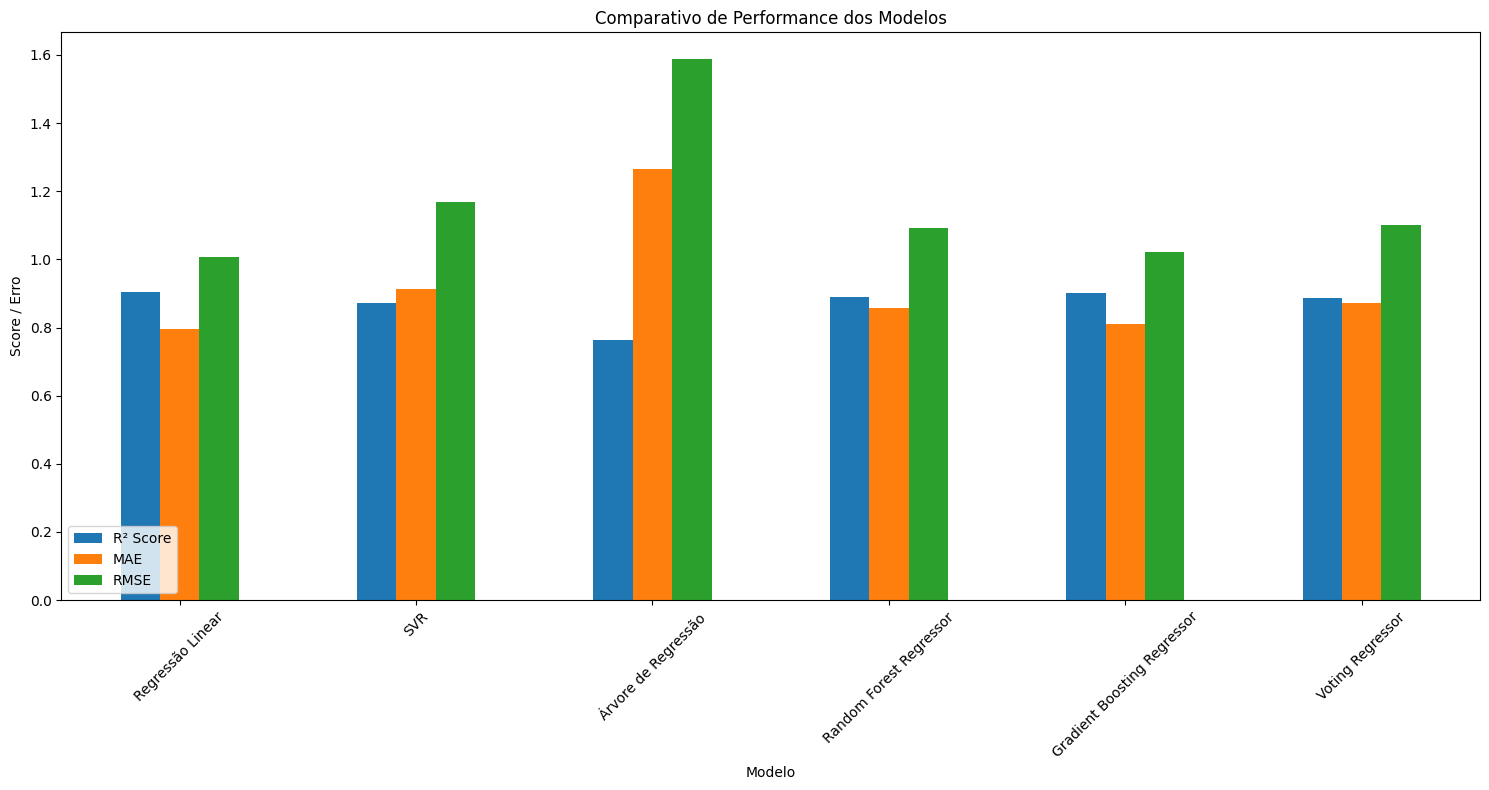

In [ ]:
# --- 5. Visualizações Obrigatórias ---
# Comparativo de Desempenho entre Modelos
plt.figure(figsize=(15, 8))
results[['R² Score', 'MAE', 'RMSE']].plot(kind='bar', figsize=(15, 8))
plt.title('Comparativo de Performance dos Modelos')
plt.ylabel('Score / Erro')
plt.xlabel('Modelo')
plt.xticks(rotation=45)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

In [33]:

# Importância dos Atributos (Feature Importance) para modelos baseados em árvore
print("\n--- Importância dos Atributos ---")

# Random Forest Regressor
importances_rfr = rfr.feature_importances_
feature_names = X_treino_final.columns
feature_importance_rfr = pd.Series(importances_rfr, index=feature_names).sort_values(ascending=False)

# Gradient Boosting Regressor
importances_gbr = gbr.feature_importances_
feature_importance_gbr = pd.Series(importances_gbr, index=feature_names).sort_values(ascending=False)

# Criar um DataFrame para comparar a importância das features
importance_df = pd.DataFrame({
    'Random Forest': feature_importance_rfr,
    'Gradient Boosting': feature_importance_gbr
})

print(importance_df.head(10).to_markdown(numalign="left", stralign="left"))



--- Importância dos Atributos ---
|     | Random Forest   | Gradient Boosting   |
|:----|:----------------|:--------------------|
| f0  | 0.00984674      | 0.0230093           |
| f1  | 0.00157937      | 0.000205226         |
| f10 | 0.519024        | 0.521192            |
| f11 | 0.00214165      | 0.000171575         |
| f12 | 0.306052        | 0.316743            |
| f13 | 0.0110358       | 0.00850982          |
| f14 | 0.00162677      | 8.14078e-05         |
| f15 | 0.0013774       | 7.76437e-05         |
| f16 | 0.000864622     | 8.97887e-05         |
| f17 | 0.001873        | 0.000226299         |


Text(0, 0.5, 'Feature')

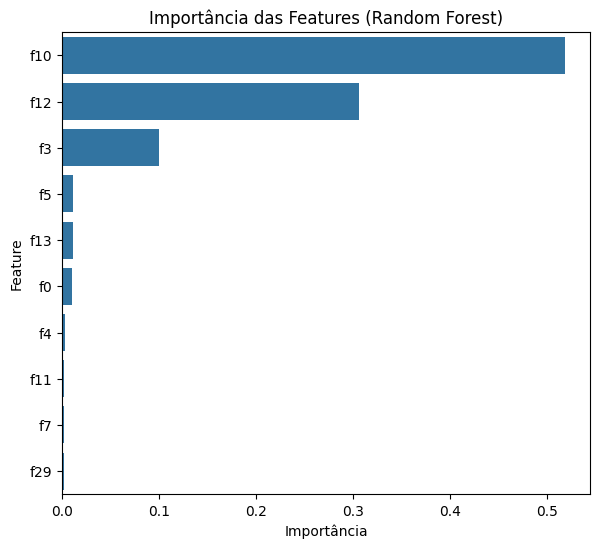

In [34]:
# Visualização da Importância das Features
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.barplot(x=feature_importance_rfr.head(10), y=feature_importance_rfr.head(10).index)
plt.title('Importância das Features (Random Forest)')
plt.xlabel('Importância')
plt.ylabel('Feature')

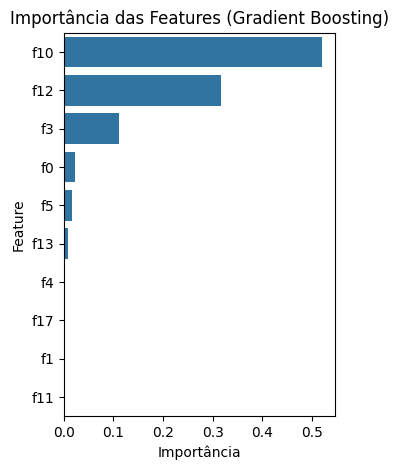

In [35]:

plt.subplot(1, 2, 2)
sns.barplot(x=feature_importance_gbr.head(10), y=feature_importance_gbr.head(10).index)
plt.title('Importância das Features (Gradient Boosting)')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [36]:

# Base learners mais influentes (análise do Voting Regressor)
print("\n--- Análise do Voting Regressor ---")
# O Voting Regressor não tem uma importância de features direta. 
# A influência dos base learners é melhor analisada pelos pesos (se aplicados) 
# ou pela performance individual de cada um.
print("A influência dos base learners no Voting Regressor pode ser analisada pelo 'R² Score' individual de cada um, ou pela customização dos 'weights'.")
print("Os modelos de ensemble baseados em Boosting e Bagging geralmente superam os modelos de base.")


--- Análise do Voting Regressor ---
A influência dos base learners no Voting Regressor pode ser analisada pelo 'R² Score' individual de cada um, ou pela customização dos 'weights'.
Os modelos de ensemble baseados em Boosting e Bagging geralmente superam os modelos de base.
